In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Loading Data

In [2]:
data = pd.read_csv('sample.csv')
data.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [4]:
data.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [5]:
data.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [6]:
data[data.duplicated(keep = False)]


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status


The dataset contains 58,645 observations and 13 total columns. There are no missing values and no duplicated entries. 

## Univariate EDA

### Loan Status (Target Variable)

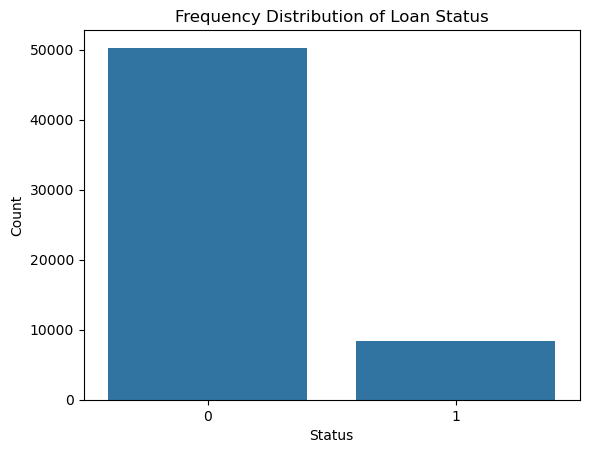

In [7]:
sns.countplot(data = data, x = data['loan_status'])
plt.title('Frequency Distribution of Loan Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

In [8]:
data['loan_status'].value_counts(normalize= True) * 100

loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64

Loan status is a binary variable representing the outcome of the loan: whether the loan resulted in default (1) or was repaid as expected (0). Repaid loans make up 85.8 percent of the data, while defaulted loans make up the remaining 14.2%. This variable is fairly imbalanced, with a repaid to default ratio of about 6:1. This will need to be addressed during training and modeling by looking at metrics other than accuracy (such as precision, recall, F1 score or AUC) and stratifying the train/test splits to preserve this ratio. 

### Age 

In [9]:
data['person_age'].describe()

count    58645.000000
mean        27.550857
std          6.033216
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        123.000000
Name: person_age, dtype: float64

In [10]:
data[data['person_age'] > 100]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
47336,47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0


Text(0, 0.5, 'Count')

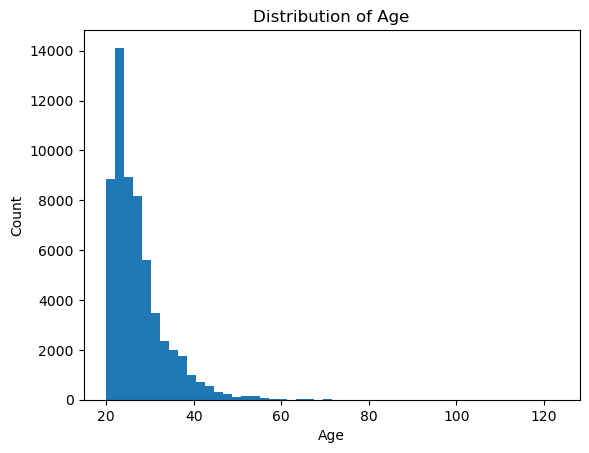

In [11]:
plt.hist(data['person_age'], bins = 50)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

In [12]:
data['person_age'].value_counts()

person_age
23     7726
22     7051
24     6395
25     5067
27     4450
26     3874
28     3707
29     3270
30     2333
31     1917
21     1795
32     1565
33     1306
36     1117
34     1041
37      992
35      862
38      745
39      536
40      438
41      433
43      320
42      291
44      229
46      164
45      163
47      125
48       97
53       75
51       69
50       63
52       62
54       60
49       59
58       35
55       34
56       29
60       28
57       25
65       13
61       13
20       12
66       11
64       10
70       10
62        7
69        6
59        6
73        3
84        2
80        2
76        1
123       1
Name: count, dtype: int64

In [13]:
data['person_age'].sort_values(ascending= False)

47336    123
4962      84
6750      84
21953     80
15588     80
        ... 
22043     20
51687     20
44496     20
8925      20
36203     20
Name: person_age, Length: 58645, dtype: int64

In [14]:
data = data[data['person_age'] != 123]
data.shape

(58644, 13)

The age variable ranges from 20 to 123, with a high concentration between 20 and 30. While it is expected for older ages to have lower counts, the highest age (123) is isolated from the rest of the data by a 39-year gap from the second highest value (84). After exploring the rest of the data, I suspect '123' corresponds to some kind of encoding and does not actually reflect the age of the person observed. Because this was only a single, isolated, outlier with a clear and significant gap from the rest of the data, I decided to drop this observation as it represents only 0.0017% of the data and would have a negligible impact on the dataset. 

### Income

In [15]:
data['person_income'].describe()

count    5.864400e+04
mean     6.404665e+04
std      3.793125e+04
min      4.200000e+03
25%      4.200000e+04
50%      5.800000e+04
75%      7.560000e+04
max      1.900000e+06
Name: person_income, dtype: float64

In [16]:
data['person_income'].quantile([0.95, 0.99, 0.999])

0.950    120000.0
0.990    175000.0
0.999    350000.0
Name: person_income, dtype: float64

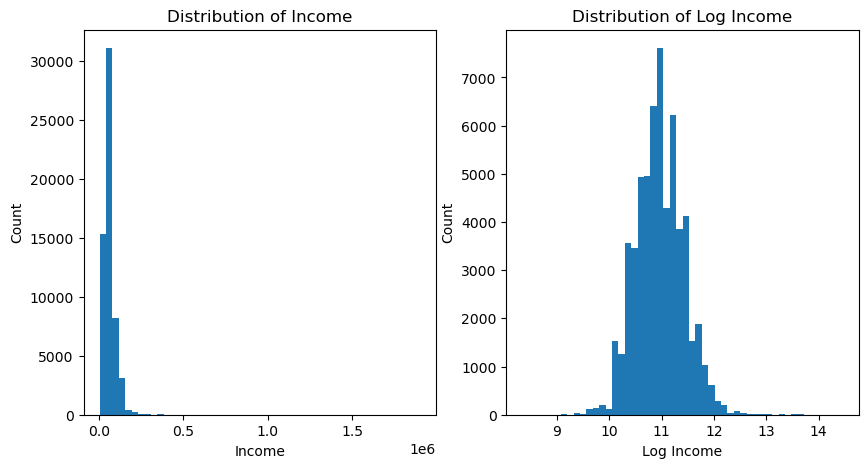

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (10,5))
axes[0].hist(data['person_income'], bins = 50)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Income')

axes[1].hist(np.log(data['person_income']), bins = 50)
axes[1].set_xlabel('Log Income')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Log Income')

plt.show()

The income variable spans a very large range, from the low thousands to $1.9M, but the 99th percentile sits at $175,000, indicating that a very small number of extremely high earners stretches the range far past where most of the data is concentrated. I observe this in the first histogram, where the data is heavily right-skewed with a long tail stretching to very high values. This skew will matter for future modeling, as logistic regression assumes a normal distribution, so a log-transformed income may be a better fit for that model. I plan to test the log-transformed income for the baseline logistic regression, but keep the raw income for tree-based models

### Home Ownership

In [18]:
data['person_home_ownership'].value_counts()

person_home_ownership
RENT        30594
MORTGAGE    24823
OWN          3138
OTHER          89
Name: count, dtype: int64

<Axes: xlabel='person_home_ownership', ylabel='count'>

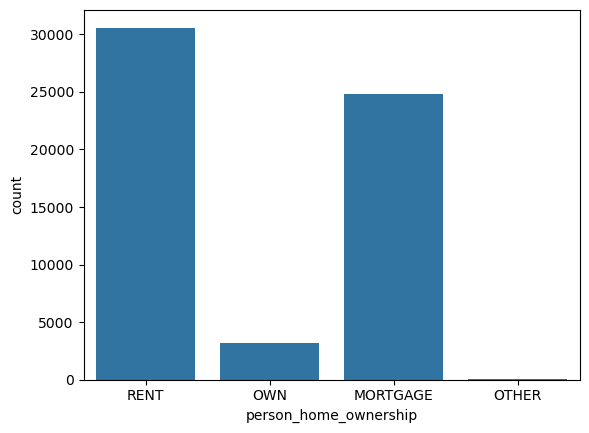

In [19]:
sns.countplot(data = data, x = 'person_home_ownership')

In [20]:
(data['person_home_ownership'].value_counts() / len(data)) * 100

person_home_ownership
RENT        52.169020
MORTGAGE    42.328286
OWN          5.350931
OTHER        0.151763
Name: count, dtype: float64

The home ownership variable only takes on four values: RENT (52%), MORTGAGE (42%), OWN (5%), and OTHER (0.15%), with the vast majority falling into the RENT and MORTGAGE categories. OTHER is a very small category and may need to be monitored/addressed during modeling. Additionally, since home ownership is a categorical variable with no inherent order, one-hot encoding will have to be applied during modeling. 

### Employment Length

In [21]:
data['person_emp_length'].describe()

count    58644.000000
mean         4.700975
std          3.959807
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [22]:
data['person_emp_length'].quantile([0.95, 0.99, 0.999])

0.950    12.000
0.990    17.000
0.999    23.357
Name: person_emp_length, dtype: float64

In [23]:
data

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


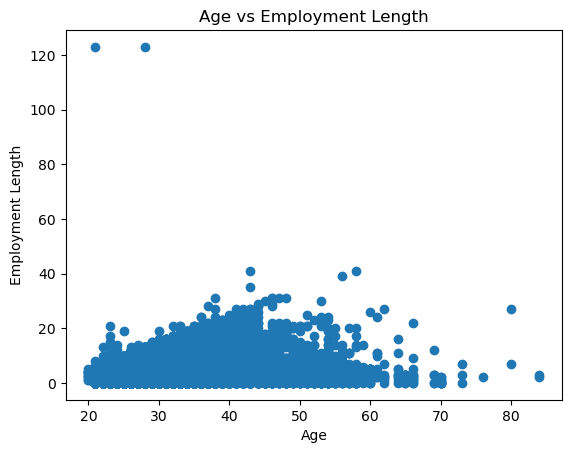

In [24]:
plt.scatter(x = data['person_age'], y = data['person_emp_length'])
plt.xlabel('Age')
plt.ylabel('Employment Length')
plt.title('Age vs Employment Length')
plt.show()

This chart plots a person's age vs. their employment length and serves two purposes: confirming what person_emp_length refers to and identifying anomolies in the data. Besides two clear outliers, employment length values are scattered across all ages, rather than forming a tight diagonal line in relation to age. Low employment length values appear among both younger and older applicants, which is inconsistent with a cumulative measure of employment across a lifetime. Two points are clearly isolated from the rest of the data, where applicants aged ~20 and ~28 have an employment length near 123 years and are separated from the next-highest values by a significant gap. These are addressed in the steps below. 

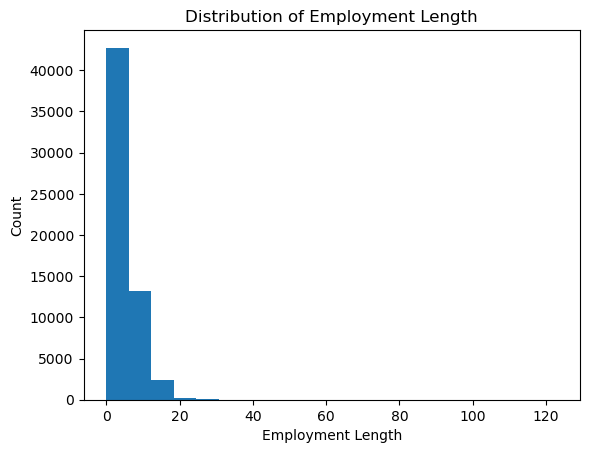

In [25]:
plt.hist(data['person_emp_length'], bins = 20)
plt.xlabel('Employment Length')
plt.ylabel('Count')
plt.title('Distribution of Employment Length')
plt.show()

This plot shows the distribution of employment length, where the data is mostly concentrated between 0 and 20 years and exhibits a heavy right skew and has along tail stretching to higher values. This is likely due to the outliers observed in the previous chart and will be addressed in the steps below.

In [26]:
print((data['person_emp_length'] == 123).sum())

2


In [27]:
data['person_emp_length'].sort_values(ascending= False)

41079    123.0
49252    123.0
9997      41.0
26125     41.0
50559     39.0
         ...  
13844      0.0
13851      0.0
29228      0.0
13857      0.0
0          0.0
Name: person_emp_length, Length: 58644, dtype: float64

In [28]:
data[data['person_emp_length'] == 123]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
49252,49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0


In [29]:
#setting age 15 as the youngest plausible working age
implausible = data[data['person_emp_length'] > (data['person_age'] - 15)]
print(len(implausible))
print(len(implausible) / len(data) * 100, '% of rows')

50
0.085260214173658 % of rows


In [30]:
implied_start_age = data['person_age'] - data['person_emp_length']
implied_start_age.value_counts().sort_index().head(20)
#natural cluster around 15/16 -- plausible early employment; near zero start dates are implausible

-102.0        1
-95.0         1
 2.0          2
 6.0          2
 7.0          1
 8.0          2
 9.0          3
 10.0         1
 11.0         3
 12.0         7
 13.0         5
 14.0        22
 15.0       932
 16.0     12712
 17.0      1640
 18.0      2477
 19.0      3151
 20.0      3514
 21.0      3879
 22.0      4254
Name: count, dtype: int64

In [31]:
implausible_start_age = data[implied_start_age < 15]
(implausible_start_age['person_age'] - implausible_start_age['person_emp_length']).describe()

count     50.000000
mean       7.380000
std       22.054561
min     -102.000000
25%       10.250000
50%       13.000000
75%       14.000000
max       14.000000
dtype: float64

In [32]:
data = data[implied_start_age >= 15].reset_index(drop = True)
data.shape

(58594, 13)

To assess whether person_emp_length reflected years of employment at a current job or over cumulative lifetime employment, I plotted age vs. employment length. The plot shows low employment length values across all ages including older applicants (60+), which would be inconsistent with a measure of cumulative lifetime employment. Therefore, I interpret person_emp_length as the number of years worked at a person's *current* job. 

The number of years at any single job cannot exceed the total time since a person was old enough to work at all (assumed here as age 15). Initially, values of employment length ranged from 0 to 123 years, where the maximuum was isolated by an 82 year gap from the next-highest value, which is likely a data entry error/data encoding rather than a true measurement. Examining the difference between age and employment length revealed a natural cluster of observations at an implied start age of employment around 15-16. A separate, smaller group of 50 rows (0.09% of the data) implied a start age below 15, which is implausible under US labor laws. Therefore, because this subset made up such a small proportion of the data, I decided to drop these observations. 

### Loan Intent

In [33]:
data['loan_intent'].value_counts()

loan_intent
EDUCATION            12264
MEDICAL              10922
PERSONAL             10007
VENTURE               9998
DEBTCONSOLIDATION     9125
HOMEIMPROVEMENT       6278
Name: count, dtype: int64

In [34]:
(data['loan_intent'].value_counts() / len(data)) * 100

loan_intent
EDUCATION            20.930471
MEDICAL              18.640134
PERSONAL             17.078540
VENTURE              17.063181
DEBTCONSOLIDATION    15.573267
HOMEIMPROVEMENT      10.714408
Name: count, dtype: float64

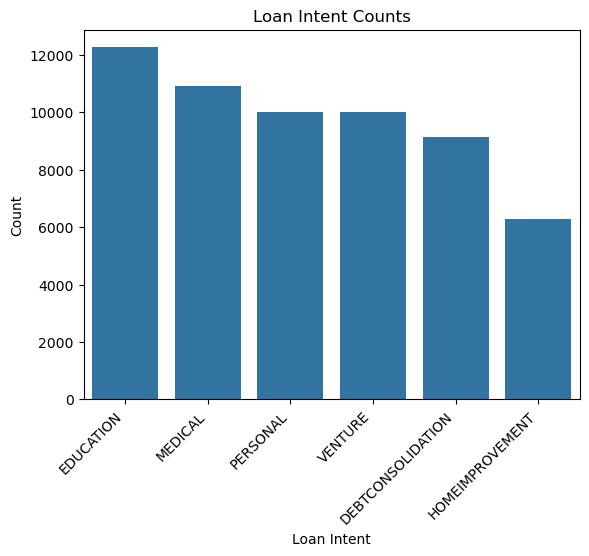

In [35]:
sns.countplot(data = data, x = 'loan_intent')
plt.xlabel('Loan Intent')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Count')
plt.title('Loan Intent Counts')
plt.show()

Loan intent is a categorical variable  consisting of 6 classes: EDUCATION, MEDICAL, PERSONAL, VENTURE, DEBTCONSOLIDATION, and HOMEIMPROVEMENT, with observations somewhat evenly spread across them. Since this is a categorical variable with no inherent order, one-hot encoding will have to be applied during modeling. 

### Loan Grade

In [36]:
data['loan_grade'].value_counts()

loan_grade
A    20965
B    20382
C    11030
D     5028
E     1007
F      149
G       33
Name: count, dtype: int64

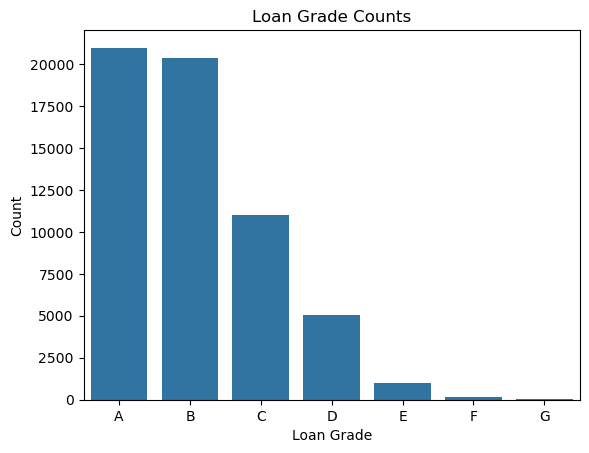

In [37]:
sns.countplot(data = data, x = 'loan_grade', order = sorted(data['loan_grade'].unique()))
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.title('Loan Grade Counts')
plt.show()

Loan grade is a categorical variable representing the creditworthiness of a borrower and the risk level of the loan. Risk is categorized into tiers, represented by letter grades A through G. Most observations appear in the A and B classes, with fewer observations as the grades get lower. Because loan grade is an ordinal categorical variable, it will have to be encoded ordinally (ex: G:1, F:2, ... A:7) during training and modeling in order to preserve the direction of the relationship. 

### Loan Amount

In [38]:
data['loan_amnt'].describe()

count    58594.000000
mean      9215.826740
std       5562.215785
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

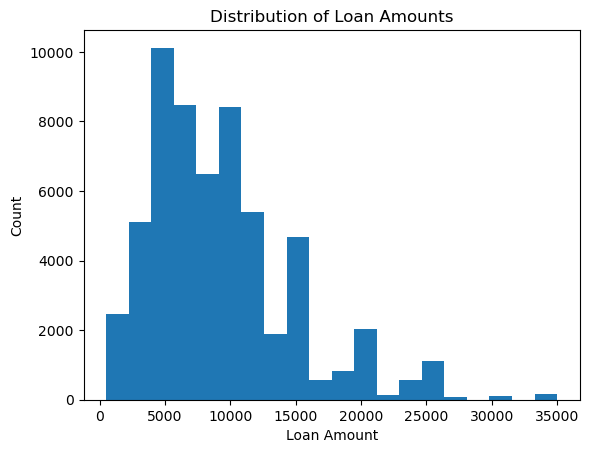

In [39]:
plt.hist(data['loan_amnt'], bins = 20)
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.title('Distribution of Loan Amounts')
plt.show()

Loan amount is a numerical variable with a range between $500 and $35,000 and most concentration between $5,000 and $12,000, and a right-skew distribution. However, even throughout the long tail, there are local spikes in loan amounts at every $5,000. This is likely due to round-number clustering, as loan terms are more common round figures like $20k and $25k rather than having a smooth, continuous distribution. There are no implausible outliers like there were in person_age and person_income, and the full range of values is consistent with realistic loan amounts. Because of the skew, for the logistic regression model, loan amount will need to be log-transformed, and raw values will be used in tree models. 

### Loan Interest Rate

In [40]:
data['loan_int_rate'].describe()

count    58594.000000
mean        10.677721
std          3.034334
min          5.420000
25%          7.880000
50%         10.750000
75%         12.990000
max         23.220000
Name: loan_int_rate, dtype: float64

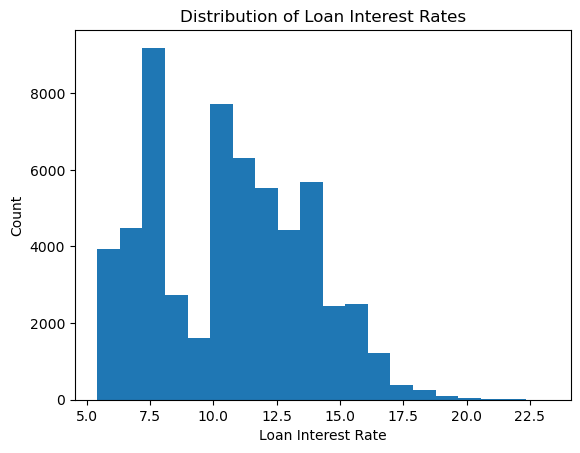

In [41]:
plt.hist(data['loan_int_rate'], bins = 20)
plt.xlabel('Loan Interest Rate')
plt.ylabel('Count')
plt.title('Distribution of Loan Interest Rates')
plt.show()

Loan interest rate ranges from 5.42% to 23.22%, with a multimodal distribution rather than skewed or a single smooth peak. 23% is a fairly high interest rate, however it may not be indicative of a data entry error, as higher-risk loan grades are likely associated with higher interest rates. 

### Loan Percent Income

In [42]:
data['loan_percent_income'].describe()

count    58594.000000
mean         0.159223
std          0.091686
min          0.000000
25%          0.090000
50%          0.140000
75%          0.210000
max          0.830000
Name: loan_percent_income, dtype: float64

In [43]:
implied_pct = data['loan_amnt']/data['person_income']
diff = (implied_pct - data['loan_percent_income']).abs()
diff.sort_values(ascending= False)

42173    2.815000
40091    2.354167
53709    1.703939
35408    1.130000
39686    1.070476
           ...   
25998    0.000000
25992    0.000000
25988    0.000000
25982    0.000000
58593    0.000000
Length: 58594, dtype: float64

In [44]:
(diff == 0).sum()

10260

In [45]:
implausible = data[implied_pct > 1].copy()
implausible['direct_calc'] = implausible['loan_amnt'] / implausible['person_income']
implausible[['loan_amnt', 'person_income', 'loan_percent_income', 'direct_calc']]

,loan_amnt,person_income,loan_percent_income,direct_calc
35408,15000,12000,0.12,1.250000
39686,5000,4200,0.12,1.190476
40091,25000,9600,0.25,2.604167
42173,30000,9600,0.31,3.125000
49139,16000,12000,0.83,1.333333
53709,25000,13200,0.19,1.893939


In [46]:
implied_pct = data['loan_amnt']/data['person_income']
data = data[implied_pct <= 1].reset_index(drop= True)
data.shape

(58588, 13)

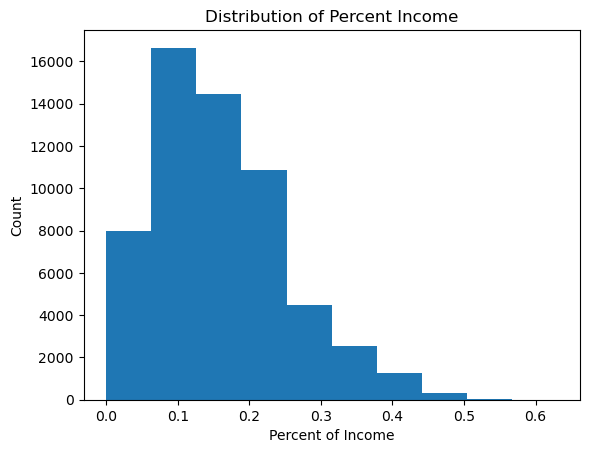

In [47]:
plt.hist(data['loan_percent_income'])
plt.xlabel('Percent of Income')
plt.ylabel('Count')
plt.title('Distribution of Percent Income')
plt.show()

Loan percent income represents the loan amount as a share of annual income, and ranges from 0 to 0.83, where 0.83 corresponds to a borrowed amount equal to 83% of that person's income. A majority of the observations are concentrated between 0.1 and 0.2, with a right-skewed shape similar to income and loan amount. 

As a consistency check, I compared loan percent income to loan_amount/person_income calculated directly. About one quarter of the observations (10,260) match exactly, and the majority of the remaining (48,334) differ only slightly, likely due to rounding rather than an error. However, a small number of rows show a larger discrepancy (up to 2.815), which may be an actual data entry error rather than rounding issues. Six rows were identified as having a difference between these values greater than 1. loan_percent_income remains within the dataset's realistic range, while the directly calculated ratio exceeded 1.0 in every case, and in some cases exceeded 3x the annual income. Given the small number of affected rows (6 of 58,594 or 0.01%), these rows were dropped. 


### Person Default

In [48]:
data['cb_person_default_on_file'].value_counts()

cb_person_default_on_file
N    49897
Y     8691
Name: count, dtype: int64

In [49]:
data['cb_person_default_on_file'].value_counts(normalize= True) * 100

cb_person_default_on_file
N    85.165904
Y    14.834096
Name: proportion, dtype: float64

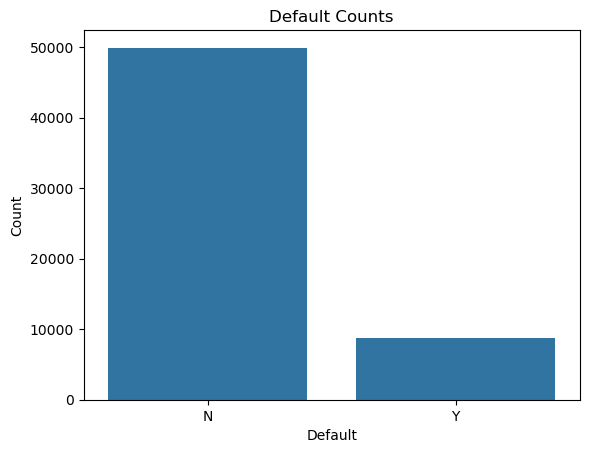

In [50]:
sns.countplot(data = data, x = 'cb_person_default_on_file')
plt.xlabel('Default')
plt.ylabel('Count')
plt.title('Default Counts')
plt.show()

cb_person_default_on_file indicates whether the applicant has a prior default on record, and is a two class categorical variable, with fairly imbalanced class sizes with 'N' making up 85% of the data, and 'Y' making up the remaining 14%. This is a clean binary categorical variable with no missing values or outliers that require cleaning. When we begin training and modeling, it will need to be encoded numerically (N=0, Y=1).

### Credit History

In [51]:
data['cb_person_cred_hist_length'].describe()

count    58588.000000
mean         5.813528
std          4.029124
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: cb_person_cred_hist_length, dtype: float64

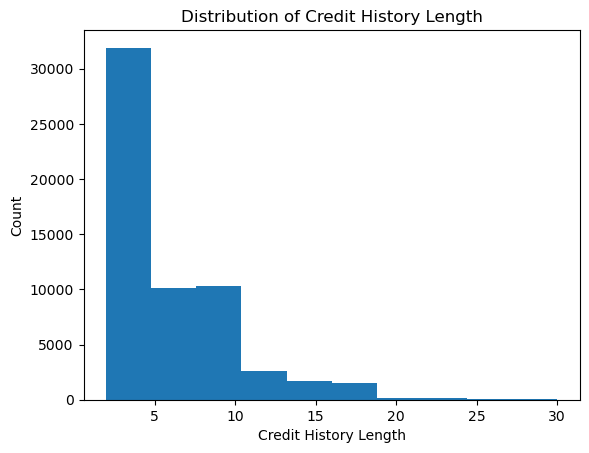

In [52]:
plt.hist(data['cb_person_cred_hist_length'])
plt.xlabel('Credit History Length')
plt.ylabel('Count')
plt.title('Distribution of Credit History Length')
plt.show()

In [53]:
implied_credit_start_age = data['person_age'] - data['cb_person_cred_hist_length']
implied_credit_start_age.describe()
implied_credit_start_age.value_counts().sort_index().head(20)

-1        1
 7        1
 8        1
 9        1
 10       1
 11       2
 12       1
 14       2
 15       6
 16      11
 17    1392
 18    4125
 19    7313
 20    9993
 21    9358
 22    8696
 23    5808
 24    3707
 25    2154
 26    1770
Name: count, dtype: int64

In [54]:
implausible_credit_start_age = data[implied_credit_start_age < 17]
(implausible_credit_start_age['person_age'] - implausible_credit_start_age['cb_person_cred_hist_length']).describe()

count    27.000000
mean     13.370370
std       3.982154
min      -1.000000
25%      11.500000
50%      15.000000
75%      16.000000
max      16.000000
dtype: float64

In [55]:
data = data[implied_credit_start_age >= 17].reset_index(drop = True)
data.shape

(58561, 13)

cb_person_cred_hist_length represents the number of years of credit a person has, which ranges from 2 to 30 years with a right tail distribution and long tails into higher values. Similar to employment length, several observations show credit history beginning at very early ages for some individuals.  Examining the difference between age and credit history length revealed a natural cluster of obsesrvations at an implied credit start age around 17. A separate, smaller group of 27 rows (0.045%) implied a credit start age below 17, which I assume to be implausible. Therefore, because this subset made up such a small proportion of the data, I decided to drop these observations. 

## Multivariate EDA

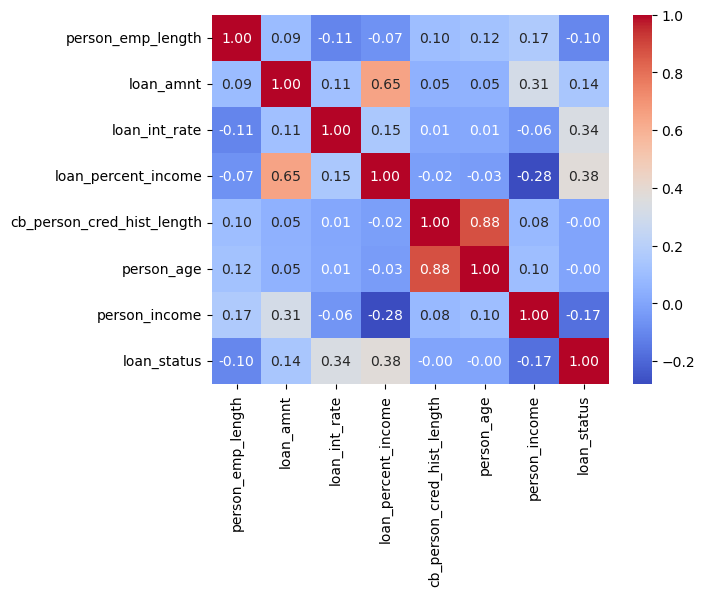

In [56]:
numerical_data = data[['person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_age', 'person_income', 'loan_status']]
corr_matrix = numerical_data.corr()
sns.heatmap(corr_matrix, annot= True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

This plot depicts a correlation heatmap between each numerical variable in the data. Based on this, loan interest rate and loan percent income are the variables that are most positively correlated with loan status, however the magnitude of these correlations (~0.3) are somewhat weak, and the other variables have a correlation close to zero, indicating no linear relationship with loan status. 

In [57]:
for col in ['loan_grade', 'person_home_ownership', 'loan_intent', 'cb_person_default_on_file']:
    print(data.groupby(col)['loan_status'].mean().sort_values(ascending= False))
    print()

loan_grade
G    0.812500
E    0.626243
F    0.610738
D    0.593669
C    0.135341
B    0.102199
A    0.049105
Name: loan_status, dtype: float64

person_home_ownership
RENT        0.222550
OTHER       0.168539
MORTGAGE    0.059467
OWN         0.013738
Name: loan_status, dtype: float64

loan_intent
DEBTCONSOLIDATION    0.188925
MEDICAL              0.178018
HOMEIMPROVEMENT      0.173781
PERSONAL             0.132860
EDUCATION            0.107702
VENTURE              0.092746
Name: loan_status, dtype: float64

cb_person_default_on_file
Y    0.298918
N    0.114992
Name: loan_status, dtype: float64




loan grade: default rate increases as loan grade gets worse, with grade G having the highest default rate (81%) and grade A having the lowest (4.9%). Grades E and F are reversed in order, but have very similar default rates. 

home ownership: RENT is the riskiest group (22.3%), while OWN is the safest (1.4%). OTHER has a high rate of default, but may be a result of having such few observations (89 rows)

loan intent: most categories have a similar default rate, ranging from 9-19%, with VENTURE being the safest and DEBTCONSOLIDATION being the riskiest

default on file: people who have defaulted have a nearly 3x higher default rate than those who have not (30% vs 11.4%)

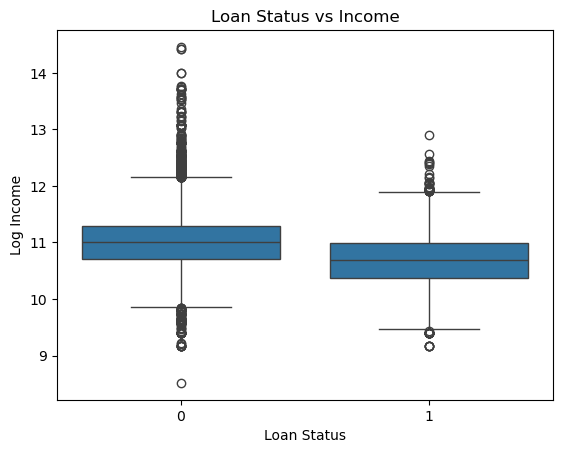

In [58]:
sns.boxplot(data = data, x = 'loan_status', y = np.log(data['person_income']))
plt.xlabel('Loan Status')
plt.ylabel('Log Income')
plt.title('Loan Status vs Income')
plt.show()

This chart compares loan status against log income. Here, those who defaulted tended to have a lower income on average, while those that repaid their loan have higher and more varied incomes. This may have to due with the fact that the loan status classes are imbalanced in the dataset; class 0 has many more observations, introducing more variance in the data.

In [59]:
income_bins = pd.qcut(data['person_income'], 10)

default_by_income = (data.groupby(income_bins)['loan_status'].mean().reset_index())
default_by_income

/var/folders/4j/njttzsjx355flj2y4dyg94080000gn/T/ipykernel_14193/2409176888.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = (data.groupby(income_bins)['loan_status'].mean().reset_index())


,person_income,loan_status
0,"(4999.999, 31200.0]",0.338279
1,"(31200.0, 39500.0]",0.267039
2,"(39500.0, 45000.0]",0.155002
3,"(45000.0, 50000.0]",0.114414
4,"(50000.0, 58000.0]",0.166876
5,"(58000.0, 63000.0]",0.101153
6,"(63000.0, 72000.0]",0.093608
7,"(72000.0, 83004.0]",0.095995
8,"(83004.0, 100000.0]",0.049314
9,"(100000.0, 1900000.0]",0.037713


Examining loan status by binned income furthers what was observed previosuly: on average, people with lower income tend to have higher default rates. The lowest income bin has the highest average default rate (33.8%) and the rate decreases as income increases, with the highest income bin having a default rate of only 3.8%.

In [60]:
pivot = data.pivot_table(values = 'loan_status', index = 'loan_grade', columns = 'person_home_ownership', aggfunc = 'mean')
pivot

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
loan_grade,,,,
A,0.012625,0.0000,0.006151,0.106414
B,0.032393,0.1250,0.005639,0.159354
C,0.089363,0.3125,0.010292,0.168344
D,0.421438,0.4000,0.033445,0.726961
E,0.350769,0.0000,0.333333,0.782609
F,0.285714,NaN,0.125000,0.826087
G,0.333333,1.0000,0.500000,0.956522


In [61]:
counts = data.pivot_table(values='loan_status', index='loan_grade', columns='person_home_ownership', aggfunc='count')
counts

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
loan_grade,,,,
A,11564.0,21.0,1138.0,8232.0
B,7872.0,40.0,1064.0,11396.0
C,3469.0,16.0,583.0,6956.0
D,1502.0,10.0,299.0,3212.0
E,325.0,1.0,36.0,644.0
F,49.0,NaN,8.0,92.0
G,6.0,1.0,2.0,23.0


Crossing loan_grade and person_home_ownership shows a similar risk gradient as before, with the RENT and MORTGAGE class' default rate climbing with worse loan grades, increasing sharply with grade D. Within the other classes, values such as 0.0, NaN, and 1.0 are present, likely reflecting the very small sample sizes within those categories. 

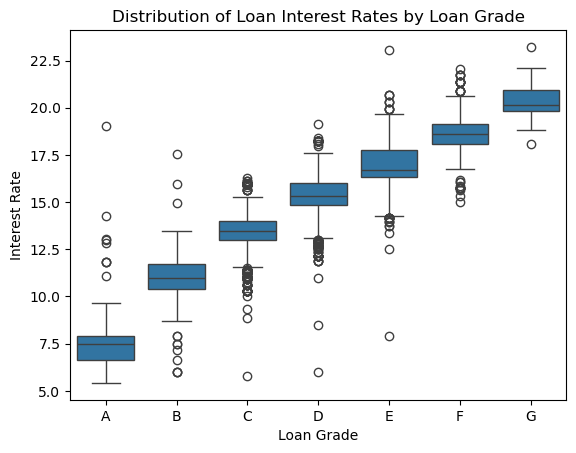

In [62]:
sns.boxplot(data=data, x = 'loan_grade', y = 'loan_int_rate', order = sorted(data['loan_grade'].unique()))
plt.title('Distribution of Loan Interest Rates by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Interest Rate')
plt.show()

Interest rates also increase as loan grades worsen, similar to default rate trends seen previously. This also explains the multimodal distribution seen earlier; each grade shows distinct, non-overlapping clusters with substantial separation between groups, ranging from ~7% to ~20.5%. Grade A shows a small group of high outliers (~11-19%), while grade D shows a cluster of low outliers (~6-8%).

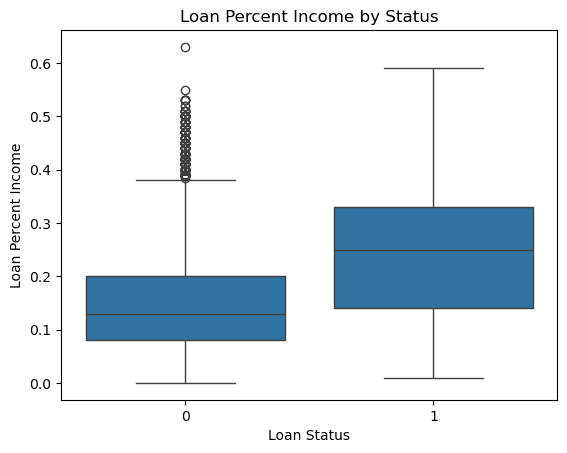

In [63]:
sns.boxplot(data = data, x = 'loan_status', y = 'loan_percent_income')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percent Income')
plt.title('Loan Percent Income by Status')
plt.show()

Loan percent income shows a clear relationship with loan status: defaulters have a noticeably higher median ratio (~0.25) than non-defaulters (~0.12), which is nearly double. This is consistent with higher debt burden compared to income being associated with higher default risk. Class 0 (non-defaulters) has many more outlying points above ~0.39, while class 1 (defaulters) have none, but this is likely due to the high variance in class zero resulting from significantly more observations. 

In [64]:
loan_bins = pd.qcut(data['loan_percent_income'], q=10)

default_rate = data.groupby(loan_bins, observed = False)['loan_status'].mean()
default_rate

loan_percent_income
(-0.001, 0.06]    0.063356
(0.06, 0.08]      0.066799
(0.08, 0.1]       0.071185
(0.1, 0.12]       0.077558
(0.12, 0.14]      0.081672
(0.14, 0.17]      0.094206
(0.17, 0.2]       0.112387
(0.2, 0.23]       0.125539
(0.23, 0.29]      0.160530
(0.29, 0.63]      0.616134
Name: loan_status, dtype: float64

Similar to the previous visualization, as the loan amount increases in terms of its proportion of income, the default rate also increases. The bin with the highest loan percent income rate has an average default rate of 61.6%, while the bin with the lowest loan as a percent of income has the lowest default rate (6.3%)

In [65]:
age_bins = pd.qcut(data['person_age'], q=10)

data.groupby(age_bins, observed = False)['loan_status'].mean()

person_age
(19.999, 22.0]    0.162575
(22.0, 23.0]      0.137837
(23.0, 24.0]      0.140263
(24.0, 25.0]      0.148075
(25.0, 26.0]      0.147995
(26.0, 27.0]      0.119037
(27.0, 29.0]      0.136259
(29.0, 31.0]      0.126707
(31.0, 36.0]      0.142469
(36.0, 84.0]      0.147436
Name: loan_status, dtype: float64

Across all age bins, the default rate remains stable between 11-16%. This suggests that age alone does not have a strong relationship with loan default risk.

## Summary

This EDA examined 58,645 loan applications across 12 (excluding id) features, with the binary target loan_status showing a notable class imbalance (85.7% repaid vs 14.2% defaulted), which will require stratified train/test splits and alternate evaluation metrics (beyond accuracy) during modeling. Data cleaning addressed a handful of implausible values: an isolated age of 123, employment ages implying a working age start below 15, inconsistencies between loan_percent_income and loan_amnt/person_income, and a small number of credit history lengths implying an implausibly early credit start, collectively removing about 0.14% of the observations. The final dataset contains 58,561 observations after the removal of implausible records. 

Univariate analysis showed right-skewed distributions for person_income and loan_amnt (suggesting a log transformation for linear models while keeping raw values for tree-based models), an ordinal loan_grade variable (that will requrie ordinal encoding for modeling), and nominal categorical variables (person_home_ownership, loan_intent, and cb_person_default_on_file) that will require one-hot encoding. 

Bivariate analysis identified loan_grade as the strongest signal of default risk, with default rates climbing from ~5% at grade A to over 80% at grade G, which is closely mirrored by rising interest rates across the same grades. loan_percent_income and cb_person_default_on_file were also meaningfully associated with higher default rates, while person_home_ownership status (RENT riskiest, OWN safest) and person_income (lower income among defaulters) showed weaker but directionally consistent relationships. These patterns point to loan_grade, loan_percent_income, loan_interest_rate, and cb_person_default_on_file as likely high-value predictors for the modeling stage. 

In [66]:
#saving cleaned dataset as a separate csv to be used for modeling
data.to_csv('cleaned_data.csv', index = False)